# LVS-VAE Head Performance Analysis

Use this notebook to evaluate LVS-VAE checkpoint performance for the outcome value head, ensembles, and live PPO progress gates.

### Setup and Dataset Load

In [144]:
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path("..").resolve()
DATASET_DIR = PROJECT_ROOT / "VAE_DATA" / "full_20k_40_40_20"

NPZ_PATH = DATASET_DIR / "states_labels.npz"
DATASET_CSV_PATH = DATASET_DIR / "dataset.csv"
METADATA_CSV_PATH = DATASET_DIR / "metadata.csv"
DATASET_PARQUET_PATH = DATASET_DIR / "dataset.parquet"
METADATA_PARQUET_PATH = DATASET_DIR / "metadata.parquet"

DATASET_DIR

WindowsPath('C:/Users/chris/OneDrive/Documents/GitHub/TNG_Falcon/VAE_DATA/full_20k_40_40_20')

In [145]:
with np.load(NPZ_PATH, allow_pickle=False) as npz_data:
    print("NPZ keys:", npz_data.files)
    states = npz_data["states"]
    labels = npz_data["labels"]
    state_columns = npz_data["state_columns"] if "state_columns" in npz_data.files else np.array([])

npz_summary_df = pd.DataFrame(
    [
        {"array": "states", "shape": states.shape, "dtype": states.dtype},
        {"array": "labels", "shape": labels.shape, "dtype": labels.dtype},
        {"array": "state_columns", "shape": state_columns.shape, "dtype": state_columns.dtype},
    ]
)
npz_summary_df

NPZ keys: ['states', 'labels', 'state_columns']


,array,shape,dtype
0,states,"(20000, 25)",int8
1,labels,"(20000,)",float32
2,state_columns,"(25,)",<U17


In [146]:
state_columns = [str(column) for column in state_columns]
npz_dataset_df = pd.DataFrame(states, columns=state_columns)
npz_dataset_df["value_label"] = labels
npz_dataset_df.head()

,cell_00,cell_01,cell_02,cell_03,cell_04,cell_05,cell_06,cell_07,cell_08,cell_09,...,cell_16,cell_17,cell_18,cell_19,cell_20,cell_21,cell_22,goats_eaten_state,phase_state,value_label
0,2,0,0,2,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.0
1,2,0,0,2,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1.0
2,2,0,2,0,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,1.0
3,0,0,2,0,2,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,1.0
4,1,2,0,0,2,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,1.0


In [147]:
def load_table(parquet_path, csv_path):
    if parquet_path.exists():
        return pd.read_parquet(parquet_path)
    if csv_path.exists():
        return pd.read_csv(csv_path)
    raise FileNotFoundError(f"Missing table: {parquet_path} or {csv_path}")


dataset_df = load_table(DATASET_PARQUET_PATH, DATASET_CSV_PATH)
metadata_df = load_table(METADATA_PARQUET_PATH, METADATA_CSV_PATH)

pd.DataFrame(
    [
        {"dataframe": "dataset_df", "rows": len(dataset_df), "columns": dataset_df.shape[1]},
        {"dataframe": "metadata_df", "rows": len(metadata_df), "columns": metadata_df.shape[1]},
    ]
)

,dataframe,rows,columns
0,dataset_df,20000,26
1,metadata_df,20000,12


## Head Analysis

Evaluate LVS-VAE checkpoints separately from dataset QA. These cells focus on the original outcome value head.

Configure one or more saved LVS-VAE checkpoints below. This evaluates each model against the currently loaded NPZ dataset.

In [148]:
MODEL_CHECKPOINTS = {
    "full_20k_final": PROJECT_ROOT / "artifacts" / "lvs_vae" / "full_20k_lvsvae_v1" / "full_20k_lvsvae_v1_final_model.pt",
    "full_40k_final": PROJECT_ROOT / "artifacts" / "lvs_vae" / "full_40k_lvsvae_v1" / "full_40k_lvsvae_v1_final_model.pt",
    "end_20k_final": PROJECT_ROOT / "artifacts" / "lvs_vae" / "end_20k_lvsvae_v1" / "end_20k_lvsvae_v1_final_model.pt",
    "end_40k_final": PROJECT_ROOT / "artifacts" / "lvs_vae" / "end_40k_lvsvae_v1" / "end_40k_lvsvae_v1_final_model.pt",
    "end06_20k_final": PROJECT_ROOT / "artifacts" / "lvs_vae" / "end06_20k_lvsvae_v1" / "end06_20k_lvsvae_v1_final_model.pt",

}

ENSEMBLE_MODELS = {}

PHASE_GATED_ENSEMBLES = {
    "phase_gated_full40_end40": {
        "full_members": ["full_40k_final", "full_20k_final"],
        "full_weights": None,
        "end_members": ["end_40k_final", "end_20k_final", "end06_20k_final"],
        "end_weights": None,
        "progress_threshold": .7,
        "endgame_weight_after_threshold": .7,
    },
}

EVALUATION_DEVICE = "cpu"
EVALUATION_BATCH_SIZE = 512
EVALUATION_BETA = 0.001
EVALUATION_VALUE_WEIGHT = 1.0
SELECTED_TRAINING_CURVE_MODELS = [
    "full_20k_final",
    "full_40k_final",
    "end_20k_final",
    "end_40k_final",
]
TRAINING_CURVE_LOSSES = ["total", "reconstruction", "kl", "value"]
PREDICTION_BOXPLOT_EXCLUDED_MODELS = {"end06_20k_final"}

checkpoint_files_df = pd.DataFrame(
    [
        {
            "model_name": name,
            "model_type": "checkpoint",
            "path": str(path),
            "members": None,
            "exists": path.exists(),
        }
        for name, path in MODEL_CHECKPOINTS.items()
    ]
)
ensemble_files_df = pd.DataFrame(
    [
        {
            "model_name": name,
            "model_type": "ensemble",
            "path": None,
            "members": ", ".join(config["members"]),
            "exists": all(MODEL_CHECKPOINTS[member].exists() for member in config["members"]),
        }
        for name, config in ENSEMBLE_MODELS.items()
    ]
)
phase_gated_files_df = pd.DataFrame(
    [
        {
            "model_name": name,
            "model_type": "phase_gated_ensemble",
            "path": None,
            "members": ", ".join(config["full_members"] + config["end_members"]),
            "exists": all(
                MODEL_CHECKPOINTS[member].exists()
                for member in config["full_members"] + config["end_members"]
            ),
        }
        for name, config in PHASE_GATED_ENSEMBLES.items()
    ]
)
model_files_df = pd.concat(
    [checkpoint_files_df, ensemble_files_df, phase_gated_files_df],
    ignore_index=True,
)
model_files_df

,model_name,model_type,path,members,exists
0,full_20k_final,checkpoint,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,None,True
1,full_40k_final,checkpoint,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,None,True
2,end_20k_final,checkpoint,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,None,True
3,end_40k_final,checkpoint,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,None,True
4,end06_20k_final,checkpoint,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,None,True
5,phase_gated_full40_end40,phase_gated_ensemble,None,"full_40k_final, full_20k_final, end_40k_final,...",True


In [149]:
import sys
import torch
from torch.utils.data import DataLoader, TensorDataset

vae_dir = PROJECT_ROOT / "VAE"
if str(vae_dir) not in sys.path:
    sys.path.append(str(vae_dir))

from LVS_VAE import LVSVAE, lvs_vae_loss


def load_lvs_vae_checkpoint(checkpoint_path, device):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    config = checkpoint.get("config", {})

    model = LVSVAE(
        input_dim=int(config.get("input_dim", 25)),
        latent_dim=int(config.get("latent_dim", 8)),
        hidden_dims=tuple(config.get("hidden_dims", (64, 64))),
        value_hidden_dim=int(config.get("value_hidden_dim", 32)),
    ).to(device)
    model.load_state_dict(checkpoint["model_state_dict"], strict=False)
    model.eval()
    return model, checkpoint, config


def find_training_metrics_csv(checkpoint_path, config):
    run_name = config.get("run_name")
    if run_name:
        metrics_path = checkpoint_path.parent / f"{run_name}_metrics.csv"
        if metrics_path.exists():
            return metrics_path

    metrics_files = sorted(checkpoint_path.parent.glob("*_metrics.csv"))
    return metrics_files[0] if metrics_files else None


def load_training_time_summary(checkpoint_path, config):
    metrics_path = find_training_metrics_csv(checkpoint_path, config)
    if metrics_path is None:
        return {
            "metrics_path": None,
            "run_elapsed_time": None,
        }

    metrics_df = pd.read_csv(metrics_path)
    if metrics_df.empty or "elapsed_time" not in metrics_df.columns:
        return {
            "metrics_path": str(metrics_path),
            "run_elapsed_time": None,
        }

    final_row = metrics_df.iloc[-1]
    return {
        "metrics_path": str(metrics_path),
        "run_elapsed_time": final_row.get("elapsed_time"),
    }


def evaluate_lvs_vae_model(model, states_array, labels_array, device):
    states_tensor = torch.as_tensor(states_array, dtype=torch.float32)
    labels_tensor = torch.as_tensor(labels_array, dtype=torch.float32)
    loader = DataLoader(
        TensorDataset(states_tensor, labels_tensor),
        batch_size=EVALUATION_BATCH_SIZE,
        shuffle=False,
    )

    loss_totals = {"total": 0.0, "reconstruction": 0.0, "kl": 0.0, "value": 0.0}
    prediction_batches = []
    label_batches = []
    row_count = 0

    with torch.no_grad():
        for batch_states, batch_labels in loader:
            batch_states = batch_states.to(device)
            batch_labels = batch_labels.to(device)
            batch_size = len(batch_states)

            outputs = model(batch_states)
            losses = lvs_vae_loss(
                model=model,
                states=batch_states,
                value_labels=batch_labels,
                outputs=outputs,
                beta=EVALUATION_BETA,
                value_weight=EVALUATION_VALUE_WEIGHT,
            )

            loss_totals["total"] += losses.total.item() * batch_size
            loss_totals["reconstruction"] += losses.reconstruction.item() * batch_size
            loss_totals["kl"] += losses.kl.item() * batch_size
            loss_totals["value"] += losses.value.item() * batch_size

            prediction_batches.append(outputs["value"].detach().cpu().view(-1))
            label_batches.append(batch_labels.detach().cpu().view(-1))
            row_count += batch_size

    predictions = torch.cat(prediction_batches)
    true_labels = torch.cat(label_batches)
    errors = predictions - true_labels

    return {
        "rows": row_count,
        "total_loss": loss_totals["total"] / row_count,
        "reconstruction_loss": loss_totals["reconstruction"] / row_count,
        "kl_loss": loss_totals["kl"] / row_count,
        "value_mse": loss_totals["value"] / row_count,
        "value_rmse": float(torch.sqrt(torch.mean(errors.pow(2))).item()),
        "value_mae": float(torch.mean(torch.abs(errors)).item()),
        "prediction_mean": float(predictions.mean().item()),
        "prediction_std": float(predictions.std(unbiased=False).item()),
        "predictions": predictions.numpy(),
        "labels": true_labels.numpy(),
    }


def normalize_ensemble_weights(weights, member_count):
    if weights is None:
        weights = [1.0 / member_count] * member_count
    if len(weights) != member_count:
        raise ValueError(f"Expected {member_count} ensemble weights, got {len(weights)}")

    weights = np.asarray(weights, dtype=np.float32)
    weight_sum = weights.sum()
    if weight_sum <= 0:
        raise ValueError("Ensemble weights must sum to a positive value")
    return weights / weight_sum


def evaluate_lvs_vae_ensemble(models, weights, states_array, labels_array, device):
    states_tensor = torch.as_tensor(states_array, dtype=torch.float32)
    labels_tensor = torch.as_tensor(labels_array, dtype=torch.float32)
    loader = DataLoader(
        TensorDataset(states_tensor, labels_tensor),
        batch_size=EVALUATION_BATCH_SIZE,
        shuffle=False,
    )

    weights_tensor = torch.as_tensor(weights, dtype=torch.float32, device=device).view(1, -1)
    prediction_batches = []
    label_batches = []
    row_count = 0

    with torch.no_grad():
        for batch_states, batch_labels in loader:
            batch_states = batch_states.to(device)
            batch_labels = batch_labels.to(device)

            member_predictions = torch.cat(
                [model.predict_value(batch_states).view(-1, 1) for model in models],
                dim=1,
            )
            ensemble_predictions = (member_predictions * weights_tensor).sum(dim=1)

            prediction_batches.append(ensemble_predictions.detach().cpu())
            label_batches.append(batch_labels.detach().cpu().view(-1))
            row_count += len(batch_states)

    predictions = torch.cat(prediction_batches)
    true_labels = torch.cat(label_batches)
    errors = predictions - true_labels
    value_mse = torch.mean(errors.pow(2))

    return {
        "rows": row_count,
        "total_loss": None,
        "reconstruction_loss": None,
        "kl_loss": None,
        "value_mse": float(value_mse.item()),
        "value_rmse": float(torch.sqrt(value_mse).item()),
        "value_mae": float(torch.mean(torch.abs(errors)).item()),
        "prediction_mean": float(predictions.mean().item()),
        "prediction_std": float(predictions.std(unbiased=False).item()),
        "predictions": predictions.numpy(),
        "labels": true_labels.numpy(),
    }


def weighted_model_predictions(models, weights_tensor, batch_states):
    member_predictions = torch.cat(
        [model.predict_value(batch_states).view(-1, 1) for model in models],
        dim=1,
    )
    return (member_predictions * weights_tensor).sum(dim=1)


def evaluate_phase_gated_lvs_vae_ensemble(
    full_models,
    full_weights,
    end_models,
    end_weights,
    states_array,
    labels_array,
    progress_ratio_array,
    progress_threshold,
    endgame_weight_after_threshold,
    device,
):
    states_tensor = torch.as_tensor(states_array, dtype=torch.float32)
    labels_tensor = torch.as_tensor(labels_array, dtype=torch.float32)
    progress_tensor = torch.as_tensor(progress_ratio_array, dtype=torch.float32)
    loader = DataLoader(
        TensorDataset(states_tensor, labels_tensor, progress_tensor),
        batch_size=EVALUATION_BATCH_SIZE,
        shuffle=False,
    )

    full_weights_tensor = torch.as_tensor(
        full_weights,
        dtype=torch.float32,
        device=device,
    ).view(1, -1)
    end_weights_tensor = torch.as_tensor(
        end_weights,
        dtype=torch.float32,
        device=device,
    ).view(1, -1)

    prediction_batches = []
    label_batches = []
    row_count = 0

    with torch.no_grad():
        for batch_states, batch_labels, batch_progress in loader:
            batch_states = batch_states.to(device)
            batch_labels = batch_labels.to(device)
            batch_progress = batch_progress.to(device)

            full_predictions = weighted_model_predictions(
                full_models,
                full_weights_tensor,
                batch_states,
            )
            end_predictions = weighted_model_predictions(
                end_models,
                end_weights_tensor,
                batch_states,
            )

            late_blend = (
                (1.0 - endgame_weight_after_threshold) * full_predictions
                + endgame_weight_after_threshold * end_predictions
            )
            is_endgame = batch_progress >= progress_threshold
            predictions = torch.where(is_endgame, late_blend, full_predictions)

            prediction_batches.append(predictions.detach().cpu())
            label_batches.append(batch_labels.detach().cpu().view(-1))
            row_count += len(batch_states)

    predictions = torch.cat(prediction_batches)
    true_labels = torch.cat(label_batches)
    errors = predictions - true_labels
    value_mse = torch.mean(errors.pow(2))

    return {
        "rows": row_count,
        "total_loss": None,
        "reconstruction_loss": None,
        "kl_loss": None,
        "value_mse": float(value_mse.item()),
        "value_rmse": float(torch.sqrt(value_mse).item()),
        "value_mae": float(torch.mean(torch.abs(errors)).item()),
        "prediction_mean": float(predictions.mean().item()),
        "prediction_std": float(predictions.std(unbiased=False).item()),
        "predictions": predictions.numpy(),
        "labels": true_labels.numpy(),
    }


In [150]:
device = torch.device(EVALUATION_DEVICE)
evaluation_rows = []
prediction_frames = []
loaded_models = {}

for model_name, checkpoint_path in MODEL_CHECKPOINTS.items():
    if not checkpoint_path.exists():
        continue

    model, checkpoint, config = load_lvs_vae_checkpoint(checkpoint_path, device)
    training_time = load_training_time_summary(checkpoint_path, config)
    loaded_models[model_name] = model
    result = evaluate_lvs_vae_model(model, states, labels, device)

    evaluation_rows.append(
        {
            "model_name": model_name,
            "model_type": "checkpoint",
            "ensemble_members": None,
            "ensemble_weights": None,
            "checkpoint_path": str(checkpoint_path),
            "checkpoint_epoch": checkpoint.get("epoch"),
            "trained_run_name": config.get("run_name"),
            "trained_data_path": config.get("data_path"),
            "training_metrics_path": training_time["metrics_path"],
            "run_elapsed_time": training_time["run_elapsed_time"],
            "rows": result["rows"],
            "total_loss": result["total_loss"],
            "reconstruction_loss": result["reconstruction_loss"],
            "kl_loss": result["kl_loss"],
            "value_mse": result["value_mse"],
            "value_rmse": result["value_rmse"],
            "value_mae": result["value_mae"],
            "prediction_mean": result["prediction_mean"],
            "prediction_std": result["prediction_std"],
        }
    )

    prediction_frames.append(
        pd.DataFrame(
            {
                "model_name": model_name,
                "value_label": result["labels"],
                "value_pred": result["predictions"],
                "error": result["predictions"] - result["labels"],
                "abs_error": np.abs(result["predictions"] - result["labels"]),
            }
        )
    )

for ensemble_name, ensemble_config in ENSEMBLE_MODELS.items():
    members = ensemble_config["members"]
    missing_members = [member for member in members if member not in loaded_models]
    if missing_members:
        print(f"Skipping {ensemble_name}; missing members: {missing_members}")
        continue

    weights = normalize_ensemble_weights(ensemble_config.get("weights"), len(members))
    member_models = [loaded_models[member] for member in members]
    result = evaluate_lvs_vae_ensemble(member_models, weights, states, labels, device)

    evaluation_rows.append(
        {
            "model_name": ensemble_name,
            "model_type": "ensemble",
            "ensemble_members": ", ".join(members),
            "ensemble_weights": ", ".join(f"{weight:.3f}" for weight in weights),
            "checkpoint_path": None,
            "checkpoint_epoch": None,
            "trained_run_name": None,
            "trained_data_path": None,
            "training_metrics_path": None,
            "run_elapsed_time": None,
            "rows": result["rows"],
            "total_loss": result["total_loss"],
            "reconstruction_loss": result["reconstruction_loss"],
            "kl_loss": result["kl_loss"],
            "value_mse": result["value_mse"],
            "value_rmse": result["value_rmse"],
            "value_mae": result["value_mae"],
            "prediction_mean": result["prediction_mean"],
            "prediction_std": result["prediction_std"],
        }
    )

    prediction_frames.append(
        pd.DataFrame(
            {
                "model_name": ensemble_name,
                "value_label": result["labels"],
                "value_pred": result["predictions"],
                "error": result["predictions"] - result["labels"],
                "abs_error": np.abs(result["predictions"] - result["labels"]),
            }
        )
    )

if "progress_ratio" not in metadata_df.columns:
    print("Skipping phase-gated ensembles; metadata_df has no progress_ratio column.")
elif len(metadata_df) != len(states):
    print("Skipping phase-gated ensembles; metadata_df row count does not match states.")
else:
    progress_ratios = metadata_df["progress_ratio"].to_numpy(dtype=np.float32)

    for ensemble_name, ensemble_config in PHASE_GATED_ENSEMBLES.items():
        full_members = ensemble_config["full_members"]
        end_members = ensemble_config["end_members"]
        all_members = full_members + end_members
        missing_members = [member for member in all_members if member not in loaded_models]
        if missing_members:
            print(f"Skipping {ensemble_name}; missing members: {missing_members}")
            continue

        full_weights = normalize_ensemble_weights(
            ensemble_config.get("full_weights"),
            len(full_members),
        )
        end_weights = normalize_ensemble_weights(
            ensemble_config.get("end_weights"),
            len(end_members),
        )
        result = evaluate_phase_gated_lvs_vae_ensemble(
            full_models=[loaded_models[member] for member in full_members],
            full_weights=full_weights,
            end_models=[loaded_models[member] for member in end_members],
            end_weights=end_weights,
            states_array=states,
            labels_array=labels,
            progress_ratio_array=progress_ratios,
            progress_threshold=ensemble_config["progress_threshold"],
            endgame_weight_after_threshold=ensemble_config[
                "endgame_weight_after_threshold"
            ],
            device=device,
        )

        evaluation_rows.append(
            {
                "model_name": ensemble_name,
                "model_type": "phase_gated_ensemble",
                "ensemble_members": ", ".join(all_members),
                "ensemble_weights": (
                    f"full={', '.join(f'{weight:.3f}' for weight in full_weights)}; "
                    f"end={', '.join(f'{weight:.3f}' for weight in end_weights)}; "
                    f"endgame_blend={ensemble_config['endgame_weight_after_threshold']:.3f}"
                ),
                "checkpoint_path": None,
                "checkpoint_epoch": None,
                "trained_run_name": None,
                "trained_data_path": None,
                "training_metrics_path": None,
                "run_elapsed_time": None,
                "rows": result["rows"],
                "total_loss": result["total_loss"],
                "reconstruction_loss": result["reconstruction_loss"],
                "kl_loss": result["kl_loss"],
                "value_mse": result["value_mse"],
                "value_rmse": result["value_rmse"],
                "value_mae": result["value_mae"],
                "prediction_mean": result["prediction_mean"],
                "prediction_std": result["prediction_std"],
            }
        )

        prediction_frames.append(
            pd.DataFrame(
                {
                    "model_name": ensemble_name,
                    "value_label": result["labels"],
                    "value_pred": result["predictions"],
                    "error": result["predictions"] - result["labels"],
                    "abs_error": np.abs(result["predictions"] - result["labels"]),
                }
            )
        )

model_evaluation_df = pd.DataFrame(evaluation_rows)
if not model_evaluation_df.empty:
    model_evaluation_df = model_evaluation_df.sort_values("value_rmse", ignore_index=True)

model_predictions_df = (
    pd.concat(prediction_frames, ignore_index=True)
    if prediction_frames
    else pd.DataFrame()
)

model_evaluation_df

,model_name,model_type,ensemble_members,ensemble_weights,checkpoint_path,checkpoint_epoch,trained_run_name,trained_data_path,training_metrics_path,run_elapsed_time,rows,total_loss,reconstruction_loss,kl_loss,value_mse,value_rmse,value_mae,prediction_mean,prediction_std
0,phase_gated_full40_end40,phase_gated_ensemble,"full_40k_final, full_20k_final, end_40k_final,...","full=0.500, 0.500; end=0.333, 0.333, 0.333; en...",None,NaN,None,None,None,None,20000,NaN,NaN,NaN,0.073745,0.271561,0.189381,0.522080,0.347468
1,full_20k_final,checkpoint,None,None,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,100.0,full_20k_lvsvae_v1,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,00:01:35,20000,0.383930,0.022834,3.016886,0.080135,0.283082,0.185863,0.537029,0.369724
2,full_40k_final,checkpoint,None,None,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,100.0,full_40k_lvsvae_v1,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,00:02:47,20000,0.349339,0.020862,3.075884,0.087002,0.294961,0.209728,0.521905,0.347324
3,end06_20k_final,checkpoint,None,None,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,100.0,end06_20k_lvsvae_v1,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,00:01:29,20000,0.480442,0.039644,2.967263,0.169880,0.412165,0.250704,0.456292,0.399490
4,end_40k_final,checkpoint,None,None,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,100.0,end_40k_lvsvae_v1,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,00:03:19,20000,0.520604,0.040568,3.060615,0.178474,0.422462,0.257762,0.444795,0.400186
5,end_20k_final,checkpoint,None,None,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,100.0,end_20k_lvsvae_v1,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,00:01:29,20000,0.498044,0.043120,2.915797,0.189403,0.435204,0.264370,0.460240,0.405961


Essential training time: total elapsed time from each run's saved metrics CSV.

In [151]:
if not model_evaluation_df.empty and "run_elapsed_time" in model_evaluation_df.columns:
    elapsed_time_df = (
        model_evaluation_df[["model_name", "model_type", "run_elapsed_time"]]
        .dropna(subset=["run_elapsed_time"])
        .reset_index(drop=True)
    )
else:
    elapsed_time_df = pd.DataFrame()

elapsed_time_df

,model_name,model_type,run_elapsed_time
0,full_20k_final,checkpoint,00:01:35
1,full_40k_final,checkpoint,00:02:47
2,end06_20k_final,checkpoint,00:01:29
3,end_40k_final,checkpoint,00:03:19
4,end_20k_final,checkpoint,00:01:29


Training loss curves for the selected model runs. Edit `SELECTED_TRAINING_CURVE_MODELS` in the model config cell to choose which runs to plot.

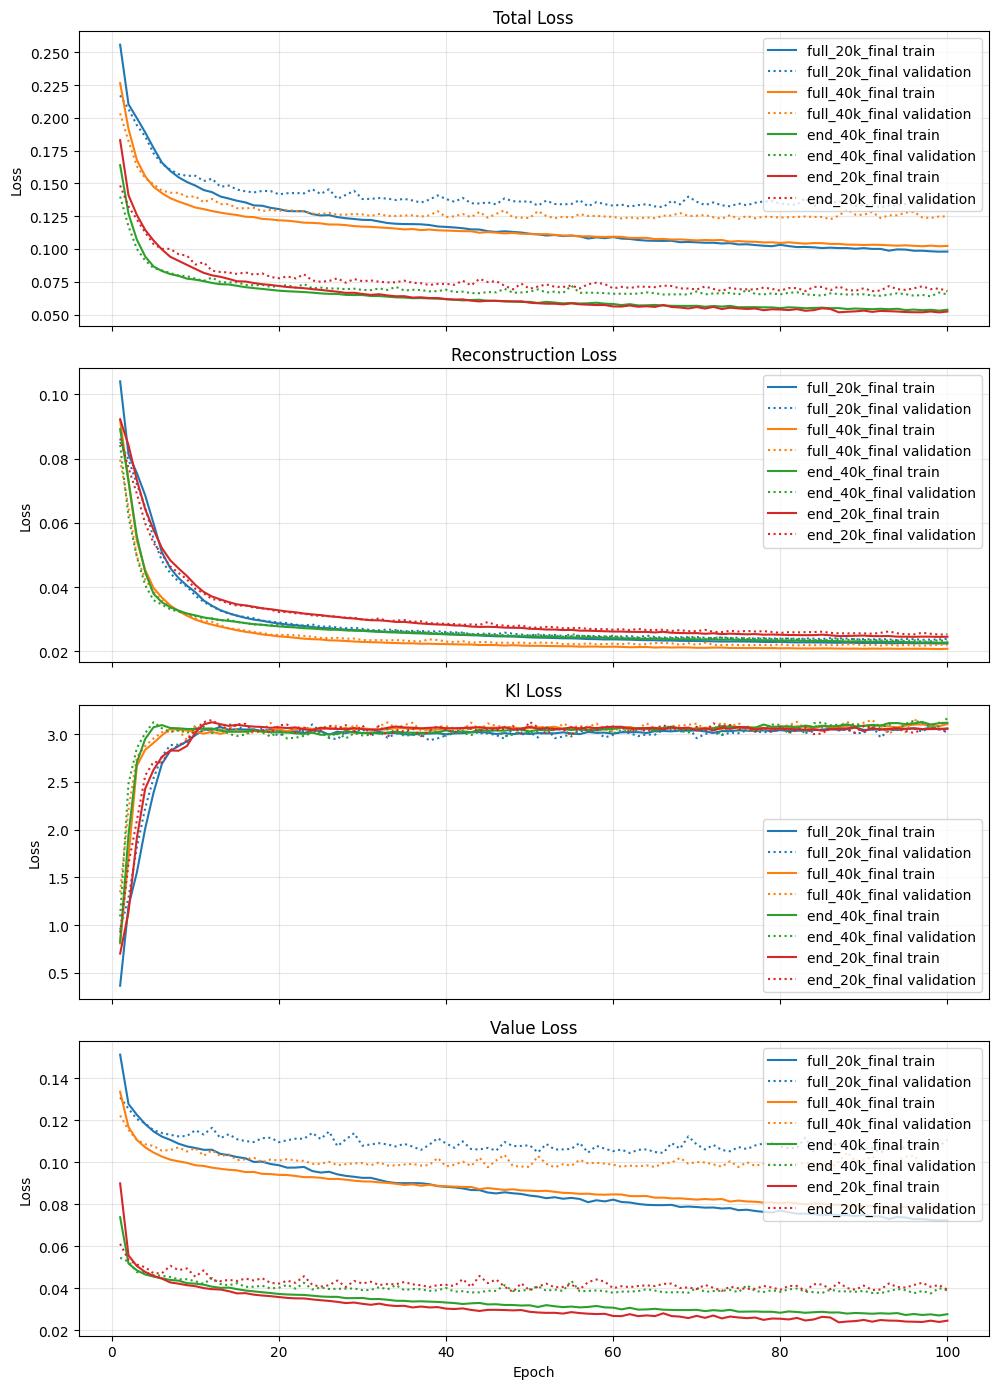

In [152]:
if model_evaluation_df.empty:
    print("No model evaluations found. Run the model evaluation cell first.")
else:
    selected_curve_rows = model_evaluation_df[
        model_evaluation_df["model_name"].isin(SELECTED_TRAINING_CURVE_MODELS)
    ].copy()
    selected_curve_rows = selected_curve_rows.dropna(subset=["training_metrics_path"])
    selected_curve_rows = selected_curve_rows.drop_duplicates(
        subset=["training_metrics_path"],
        keep="first",
    )

    if selected_curve_rows.empty:
        print("No metrics CSV files found for the selected models.")
    else:
        try:
            import matplotlib.pyplot as plt

            fig, axes = plt.subplots(
                len(TRAINING_CURVE_LOSSES),
                1,
                figsize=(10, 3.5 * len(TRAINING_CURVE_LOSSES)),
                sharex=True,
            )
            if len(TRAINING_CURVE_LOSSES) == 1:
                axes = [axes]

            color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

            for model_index, (_, model_row) in enumerate(selected_curve_rows.iterrows()):
                metrics_df = pd.read_csv(model_row["training_metrics_path"])
                label = model_row["model_name"]
                color = color_cycle[model_index % len(color_cycle)]

                for axis, loss_name in zip(axes, TRAINING_CURVE_LOSSES):
                    train_column = f"train_{loss_name}"
                    val_column = f"val_{loss_name}"
                    if train_column in metrics_df.columns:
                        axis.plot(
                            metrics_df["epoch"],
                            metrics_df[train_column],
                            color=color,
                            linestyle="-",
                            label=f"{label} train",
                        )
                    if val_column in metrics_df.columns:
                        axis.plot(
                            metrics_df["epoch"],
                            metrics_df[val_column],
                            color=color,
                            linestyle=":",
                            label=f"{label} validation",
                        )

                    axis.set_title(f"{loss_name.title()} Loss")
                    axis.set_ylabel("Loss")
                    axis.grid(True, alpha=0.3)
                    axis.legend()

            axes[-1].set_xlabel("Epoch")
            fig.tight_layout()
            plt.show()
        except ImportError:
            print("matplotlib is not installed; skipping training curve plots.")

In [153]:
if not model_predictions_df.empty:
    per_label_evaluation_df = (
        model_predictions_df
        .groupby(["model_name", "value_label"])
        .agg(
            rows=("value_pred", "size"),
            pred_mean=("value_pred", "mean"),
            pred_std=("value_pred", "std"),
            mae=("abs_error", "mean"),
            mse=("error", lambda values: np.mean(np.square(values))),
        )
        .reset_index()
    )
    per_label_evaluation_df["rmse"] = np.sqrt(per_label_evaluation_df["mse"])
else:
    per_label_evaluation_df = pd.DataFrame()

per_label_evaluation_df

,model_name,value_label,rows,pred_mean,pred_std,mae,mse,rmse
0,end06_20k_final,0.0,8000,0.197605,0.345401,0.197605,0.158335,0.397913
1,end06_20k_final,0.5,4000,0.532926,0.276286,0.211637,0.077399,0.278207
2,end06_20k_final,1.0,8000,0.676662,0.350902,0.323338,0.227665,0.477142
3,end_20k_final,0.0,8000,0.220074,0.374608,0.220074,0.188746,0.434449
4,end_20k_final,0.5,4000,0.535990,0.278381,0.206765,0.078772,0.280663
5,end_20k_final,1.0,8000,0.662531,0.362638,0.337469,0.245375,0.495354
6,end_40k_final,0.0,8000,0.191675,0.346496,0.191675,0.156784,0.395959
7,end_40k_final,0.5,4000,0.533663,0.279610,0.212421,0.079296,0.281595
8,end_40k_final,1.0,8000,0.653480,0.360130,0.346520,0.249754,0.499753
9,full_20k_final,0.0,8000,0.190482,0.256800,0.190482,0.102222,0.319721


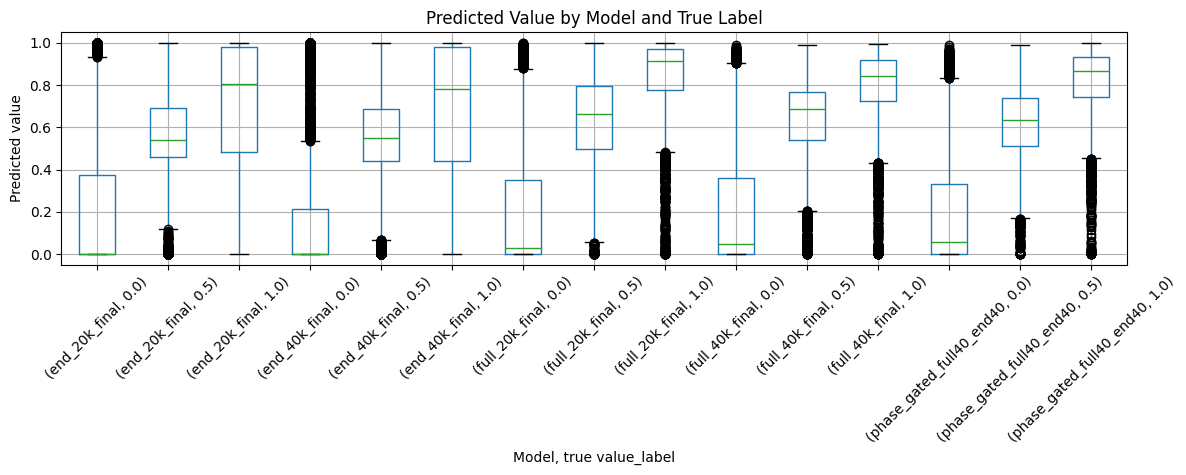

In [154]:
if not model_predictions_df.empty:
    try:
        import matplotlib.pyplot as plt

        excluded_boxplot_models = globals().get(
            "PREDICTION_BOXPLOT_EXCLUDED_MODELS",
            {"end06_20k_final"},
        )
        boxplot_predictions_df = model_predictions_df[
            ~model_predictions_df["model_name"].isin(excluded_boxplot_models)
        ].copy()

        if boxplot_predictions_df.empty:
            print("No prediction rows left after applying boxplot exclusions.")
        else:
            ax = boxplot_predictions_df.boxplot(
                column="value_pred",
                by=["model_name", "value_label"],
                figsize=(12, 5),
                rot=45,
            )
            ax.set_title("Predicted Value by Model and True Label")
            ax.set_xlabel("Model, true value_label")
            ax.set_ylabel("Predicted value")
            plt.suptitle("")
            plt.tight_layout()
            plt.show()
    except ImportError:
        print("matplotlib is not installed; skipping prediction plot.")
else:
    print("No model checkpoints found. Update MODEL_CHECKPOINTS and rerun this section.")

### Checkpoint Outcome Head Comparison

Evaluate the original outcome value head for each configured LVS-VAE checkpoint.

In [155]:
def evaluate_checkpoint_heads(model, states_array, labels_array, device):
    states_tensor = torch.as_tensor(states_array, dtype=torch.float32)
    labels_tensor = torch.as_tensor(labels_array, dtype=torch.float32)

    loader = DataLoader(
        TensorDataset(states_tensor, labels_tensor),
        batch_size=EVALUATION_BATCH_SIZE,
        shuffle=False,
    )

    outcome_predictions = []
    outcome_targets = []

    with torch.no_grad():
        for batch_states, batch_labels in loader:
            batch_states = batch_states.to(device)
            batch_labels = batch_labels.to(device)

            outcome_predictions.append(model.predict_value(batch_states).detach().cpu().view(-1))
            outcome_targets.append(batch_labels.detach().cpu().view(-1))

    predictions = torch.cat(outcome_predictions)
    targets = torch.cat(outcome_targets)
    errors = predictions - targets
    mse = torch.mean(errors.pow(2))
    return {
        "outcome_value": {
            "rows": int(len(targets)),
            "mse": float(mse.item()),
            "rmse": float(torch.sqrt(mse).item()),
            "mae": float(torch.mean(torch.abs(errors)).item()),
            "prediction_mean": float(predictions.mean().item()),
            "prediction_std": float(predictions.std(unbiased=False).item()),
            "target_mean": float(targets.mean().item()),
            "predictions": predictions.numpy(),
            "targets": targets.numpy(),
        }
    }


head_evaluation_rows = []
head_prediction_frames = []

for model_name, checkpoint_path in MODEL_CHECKPOINTS.items():
    if not checkpoint_path.exists():
        continue

    model, checkpoint, config = load_lvs_vae_checkpoint(checkpoint_path, device)
    training_time = load_training_time_summary(checkpoint_path, config)
    head_results = evaluate_checkpoint_heads(model, states, labels, device)

    for head_name, result in head_results.items():
        head_evaluation_rows.append(
            {
                "model_name": model_name,
                "head_name": head_name,
                "checkpoint_path": str(checkpoint_path),
                "trained_run_name": config.get("run_name"),
                "trained_data_path": config.get("data_path"),
                "training_metrics_path": training_time["metrics_path"],
                "run_elapsed_time": training_time["run_elapsed_time"],
                "rows": result["rows"],
                "mse": result["mse"],
                "rmse": result["rmse"],
                "mae": result["mae"],
                "prediction_mean": result["prediction_mean"],
                "prediction_std": result["prediction_std"],
                "target_mean": result["target_mean"],
            }
        )
        head_prediction_frames.append(
            pd.DataFrame(
                {
                    "model_name": model_name,
                    "head_name": head_name,
                    "target_label": result["targets"],
                    "prediction": result["predictions"],
                    "error": result["predictions"] - result["targets"],
                    "abs_error": np.abs(result["predictions"] - result["targets"]),
                }
            )
        )

head_evaluation_df = pd.DataFrame(head_evaluation_rows)
if not head_evaluation_df.empty:
    head_evaluation_df = head_evaluation_df.sort_values(
        ["head_name", "rmse"],
        ignore_index=True,
    )

head_predictions_df = (
    pd.concat(head_prediction_frames, ignore_index=True)
    if head_prediction_frames
    else pd.DataFrame()
)

head_evaluation_df

,model_name,head_name,checkpoint_path,trained_run_name,trained_data_path,training_metrics_path,run_elapsed_time,rows,mse,rmse,mae,prediction_mean,prediction_std,target_mean
0,full_20k_final,outcome_value,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,full_20k_lvsvae_v1,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,00:01:35,20000,0.080135,0.283082,0.185863,0.537029,0.369724,0.5
1,full_40k_final,outcome_value,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,full_40k_lvsvae_v1,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,00:02:47,20000,0.087002,0.294961,0.209728,0.521905,0.347324,0.5
2,end06_20k_final,outcome_value,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,end06_20k_lvsvae_v1,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,00:01:29,20000,0.169880,0.412165,0.250704,0.456292,0.399490,0.5
3,end_40k_final,outcome_value,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,end_40k_lvsvae_v1,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,00:03:19,20000,0.178474,0.422462,0.257762,0.444795,0.400186,0.5
4,end_20k_final,outcome_value,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,end_20k_lvsvae_v1,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,C:\Users\chris\OneDrive\Documents\GitHub\TNG_F...,00:01:29,20000,0.189403,0.435204,0.264370,0.460240,0.405961,0.5


In [156]:
if not head_predictions_df.empty:
    head_per_label_df = (
        head_predictions_df
        .groupby(["model_name", "head_name", "target_label"])
        .agg(
            rows=("prediction", "size"),
            pred_mean=("prediction", "mean"),
            pred_std=("prediction", "std"),
            mae=("abs_error", "mean"),
            mse=("error", lambda values: np.mean(np.square(values))),
        )
        .reset_index()
    )
    head_per_label_df["rmse"] = np.sqrt(head_per_label_df["mse"])
else:
    head_per_label_df = pd.DataFrame()

head_per_label_df

,model_name,head_name,target_label,rows,pred_mean,pred_std,mae,mse,rmse
0,end06_20k_final,outcome_value,0.0,8000,0.197605,0.345401,0.197605,0.158335,0.397913
1,end06_20k_final,outcome_value,0.5,4000,0.532926,0.276286,0.211637,0.077399,0.278207
2,end06_20k_final,outcome_value,1.0,8000,0.676662,0.350902,0.323338,0.227665,0.477142
3,end_20k_final,outcome_value,0.0,8000,0.220074,0.374608,0.220074,0.188746,0.434449
4,end_20k_final,outcome_value,0.5,4000,0.535990,0.278381,0.206765,0.078772,0.280663
5,end_20k_final,outcome_value,1.0,8000,0.662531,0.362638,0.337469,0.245375,0.495354
6,end_40k_final,outcome_value,0.0,8000,0.191675,0.346496,0.191675,0.156784,0.395959
7,end_40k_final,outcome_value,0.5,4000,0.533663,0.279610,0.212421,0.079296,0.281595
8,end_40k_final,outcome_value,1.0,8000,0.653480,0.360130,0.346520,0.249754,0.499753
9,full_20k_final,outcome_value,0.0,8000,0.190482,0.256800,0.190482,0.102222,0.319721


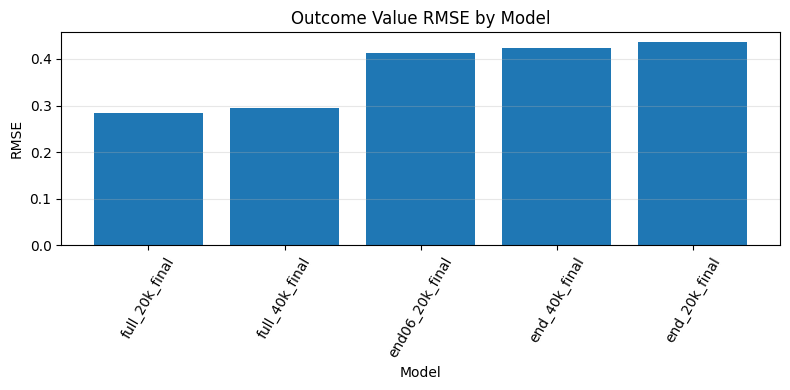

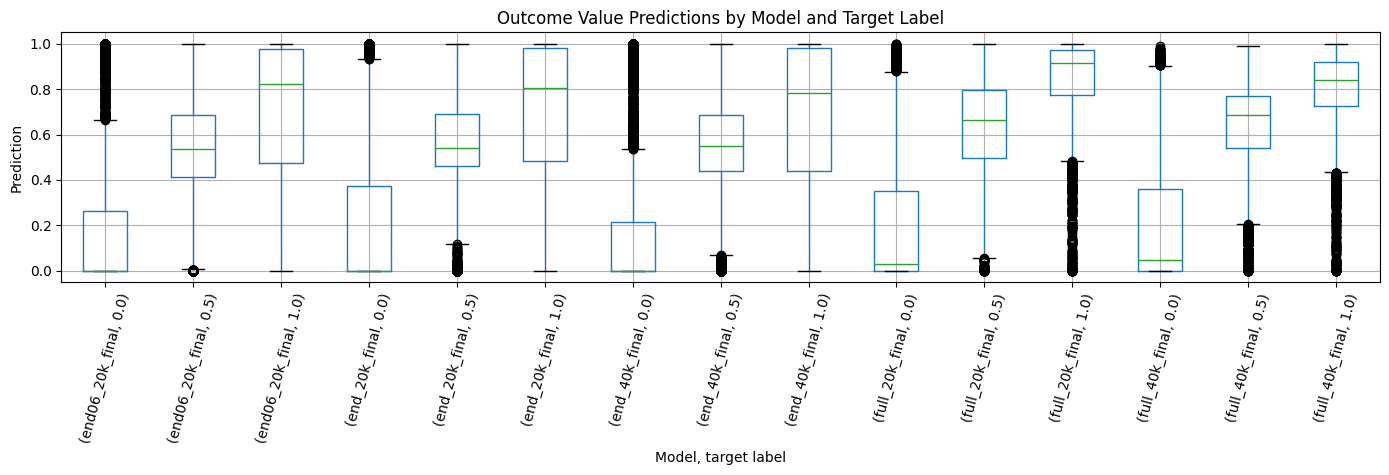

In [157]:
if head_evaluation_df.empty and head_predictions_df.empty:
    print("No checkpoint head results found. Update MODEL_CHECKPOINTS and rerun this section.")
else:
    try:
        import matplotlib.pyplot as plt

        if not head_evaluation_df.empty:
            for head_name, head_df in head_evaluation_df.groupby("head_name"):
                plot_df = head_df.sort_values("rmse")
                fig_width = max(8, len(plot_df) * 0.75)
                fig, ax = plt.subplots(figsize=(fig_width, 4))
                ax.bar(plot_df["model_name"], plot_df["rmse"])
                ax.set_title(f"{head_name.replace('_', ' ').title()} RMSE by Model")
                ax.set_xlabel("Model")
                ax.set_ylabel("RMSE")
                ax.tick_params(axis="x", rotation=60)
                ax.grid(axis="y", alpha=0.3)
                fig.tight_layout()
                plt.show()

        if not head_predictions_df.empty:
            for head_name, head_df in head_predictions_df.groupby("head_name"):
                ax = head_df.boxplot(
                    column="prediction",
                    by=["model_name", "target_label"],
                    figsize=(14, 5),
                    rot=75,
                )
                ax.set_title(f"{head_name.replace('_', ' ').title()} Predictions by Model and Target Label")
                ax.set_xlabel("Model, target label")
                ax.set_ylabel("Prediction")
                plt.suptitle("")
                plt.tight_layout()
                plt.show()
    except ImportError:
        print("matplotlib is not installed; skipping head plots.")

## Live PPO Progress Gate Comparison

Compare the current best phase-gated ensemble using the offline dataset progress ratio versus the PPO-live approximation `turn_counter / MAX_TURNS`. This is the check to run before enabling LVS-VAE shaping in PPO.


In [158]:
LIVE_GATE_MAX_TURNS = 100
LIVE_GATE_THRESHOLDS = [0.3, 0.7]
LIVE_GATE_CONFIG = {
    "full_members": ["full_40k_final", "full_20k_final"],
    "full_weights": None,
    "end_members": ["end_40k_final", "end_20k_final", "end06_20k_final"],
    "end_weights": None,
    "endgame_weight_after_threshold": .7,
}


def summarize_progress_gate_predictions(gate_name, progress_threshold, result, gate_progress_ratios):
    labels_array = result["labels"]
    predictions = result["predictions"]
    errors = predictions - labels_array
    return pd.DataFrame(
        {
            "gate_name": gate_name,
            "progress_threshold": progress_threshold,
            "value_label": labels_array,
            "value_pred": predictions,
            "error": errors,
            "abs_error": np.abs(errors),
            "gate_progress_ratio": gate_progress_ratios,
            "gate_active": gate_progress_ratios >= progress_threshold,
        }
    )


live_gate_metrics_df = pd.DataFrame()
live_gate_predictions_df = pd.DataFrame()
live_gate_per_label_df = pd.DataFrame()
live_gate_acceptance_df = pd.DataFrame()

required_gate_columns = {"progress_ratio", "move_index"}
missing_gate_columns = required_gate_columns.difference(metadata_df.columns)
missing_gate_members = [
    member
    for member in LIVE_GATE_CONFIG["full_members"] + LIVE_GATE_CONFIG["end_members"]
    if member not in loaded_models
]

if missing_gate_columns:
    print(f"Skipping live-gate comparison; metadata_df is missing columns: {sorted(missing_gate_columns)}")
elif len(metadata_df) != len(states):
    print("Skipping live-gate comparison; metadata_df row count does not match states.")
elif missing_gate_members:
    print(f"Skipping live-gate comparison; missing loaded models: {missing_gate_members}")
else:
    full_members = LIVE_GATE_CONFIG["full_members"]
    end_members = LIVE_GATE_CONFIG["end_members"]
    full_weights = normalize_ensemble_weights(LIVE_GATE_CONFIG["full_weights"], len(full_members))
    end_weights = normalize_ensemble_weights(LIVE_GATE_CONFIG["end_weights"], len(end_members))

    base_progress_inputs = {
        "dataset_progress_gate": metadata_df["progress_ratio"].to_numpy(dtype=np.float32),
        "live_turn_max_gate": np.clip(
            metadata_df["move_index"].to_numpy(dtype=np.float32) / float(LIVE_GATE_MAX_TURNS),
            0.0,
            1.0,
        ),
    }

    gate_results = {}
    live_gate_prediction_frames = []
    live_gate_metric_rows = []

    for progress_threshold in LIVE_GATE_THRESHOLDS:
        for base_gate_name, gate_progress_ratios in base_progress_inputs.items():
            gate_name = f"{base_gate_name}_threshold_{progress_threshold:.1f}"
            result = evaluate_phase_gated_lvs_vae_ensemble(
                full_models=[loaded_models[member] for member in full_members],
                full_weights=full_weights,
                end_models=[loaded_models[member] for member in end_members],
                end_weights=end_weights,
                states_array=states,
                labels_array=labels,
                progress_ratio_array=gate_progress_ratios,
                progress_threshold=progress_threshold,
                endgame_weight_after_threshold=LIVE_GATE_CONFIG["endgame_weight_after_threshold"],
                device=device,
            )
            gate_results[gate_name] = result
            live_gate_prediction_frames.append(
                summarize_progress_gate_predictions(
                    gate_name,
                    progress_threshold,
                    result,
                    gate_progress_ratios,
                )
            )
            live_gate_metric_rows.append(
                {
                    "gate_name": gate_name,
                    "progress_threshold": progress_threshold,
                    "rows": result["rows"],
                    "gated_rows": int((gate_progress_ratios >= progress_threshold).sum()),
                    "gated_ratio": float((gate_progress_ratios >= progress_threshold).mean()),
                    "value_mse": result["value_mse"],
                    "value_rmse": result["value_rmse"],
                    "value_mae": result["value_mae"],
                    "prediction_mean": result["prediction_mean"],
                    "prediction_std": result["prediction_std"],
                }
            )

    live_gate_metrics_df = pd.DataFrame(live_gate_metric_rows)
    live_gate_predictions_df = pd.concat(live_gate_prediction_frames, ignore_index=True)

    live_gate_per_label_df = (
        live_gate_predictions_df
        .groupby(["gate_name", "progress_threshold", "value_label"])
        .agg(
            rows=("value_pred", "size"),
            gated_ratio=("gate_active", "mean"),
            pred_mean=("value_pred", "mean"),
            pred_std=("value_pred", "std"),
            mae=("abs_error", "mean"),
            mse=("error", lambda values: np.mean(np.square(values))),
        )
        .reset_index()
    )
    live_gate_per_label_df["rmse"] = np.sqrt(live_gate_per_label_df["mse"])

    label_order_rows = []
    for (gate_name, progress_threshold), gate_df in live_gate_per_label_df.groupby(["gate_name", "progress_threshold"]):
        means = gate_df.set_index("value_label")["pred_mean"]
        has_all_labels = all(label in means.index for label in [0.0, 0.5, 1.0])
        clear_ordering = bool(
            has_all_labels
            and means.loc[0.0] < means.loc[0.5] < means.loc[1.0]
        )
        label_order_rows.append(
            {
                "gate_name": gate_name,
                "progress_threshold": progress_threshold,
                "pred_mean_label_0.0": means.get(0.0, np.nan),
                "pred_mean_label_0.5": means.get(0.5, np.nan),
                "pred_mean_label_1.0": means.get(1.0, np.nan),
                "keeps_0_lt_05_lt_1_ordering": clear_ordering,
            }
        )
    live_gate_acceptance_df = pd.DataFrame(label_order_rows)

live_gate_metrics_df


,gate_name,progress_threshold,rows,gated_rows,gated_ratio,value_mse,value_rmse,value_mae,prediction_mean,prediction_std
0,dataset_progress_gate_threshold_0.3,0.3,20000,13670,0.68350,0.086022,0.293296,0.206167,0.491250,0.335385
1,live_turn_max_gate_threshold_0.3,0.3,20000,5592,0.27960,0.077455,0.278308,0.195719,0.509831,0.339758
2,dataset_progress_gate_threshold_0.7,0.7,20000,5658,0.28290,0.073745,0.271561,0.189381,0.522080,0.347468
3,live_turn_max_gate_threshold_0.7,0.7,20000,1053,0.05265,0.076232,0.276101,0.192726,0.526390,0.348507


In [159]:
live_gate_per_label_df


,gate_name,progress_threshold,value_label,rows,gated_ratio,pred_mean,pred_std,mae,mse,rmse
0,dataset_progress_gate_threshold_0.3,0.3,0.0,8000,0.676875,0.186185,0.235923,0.186185,0.090317,0.300529
1,dataset_progress_gate_threshold_0.3,0.3,0.5,4000,0.693500,0.578827,0.186904,0.163521,0.041138,0.202825
2,dataset_progress_gate_threshold_0.3,0.3,1.0,8000,0.685125,0.752528,0.207200,0.247472,0.104169,0.322753
3,dataset_progress_gate_threshold_0.7,0.7,0.0,8000,0.275875,0.189965,0.238171,0.189965,0.092805,0.304639
4,dataset_progress_gate_threshold_0.7,0.7,0.5,4000,0.292500,0.613162,0.187384,0.184287,0.047910,0.218883
5,dataset_progress_gate_threshold_0.7,0.7,1.0,8000,0.285125,0.808656,0.176052,0.191344,0.067603,0.260006
6,live_turn_max_gate_threshold_0.3,0.3,0.0,8000,0.085250,0.192565,0.238747,0.192565,0.094074,0.306715
7,live_turn_max_gate_threshold_0.3,0.3,0.5,4000,0.533750,0.588509,0.186346,0.168978,0.042550,0.206277
8,live_turn_max_gate_threshold_0.3,0.3,1.0,8000,0.346875,0.787758,0.182336,0.212242,0.078289,0.279801
9,live_turn_max_gate_threshold_0.7,0.7,0.0,8000,0.001000,0.196047,0.244343,0.196047,0.098131,0.313258


In [160]:
live_gate_acceptance_df


,gate_name,progress_threshold,pred_mean_label_0.0,pred_mean_label_0.5,pred_mean_label_1.0,keeps_0_lt_05_lt_1_ordering
0,dataset_progress_gate_threshold_0.3,0.3,0.186185,0.578827,0.752528,True
1,dataset_progress_gate_threshold_0.7,0.7,0.189965,0.613162,0.808656,True
2,live_turn_max_gate_threshold_0.3,0.3,0.192565,0.588509,0.787758,True
3,live_turn_max_gate_threshold_0.7,0.7,0.196047,0.618150,0.810852,True


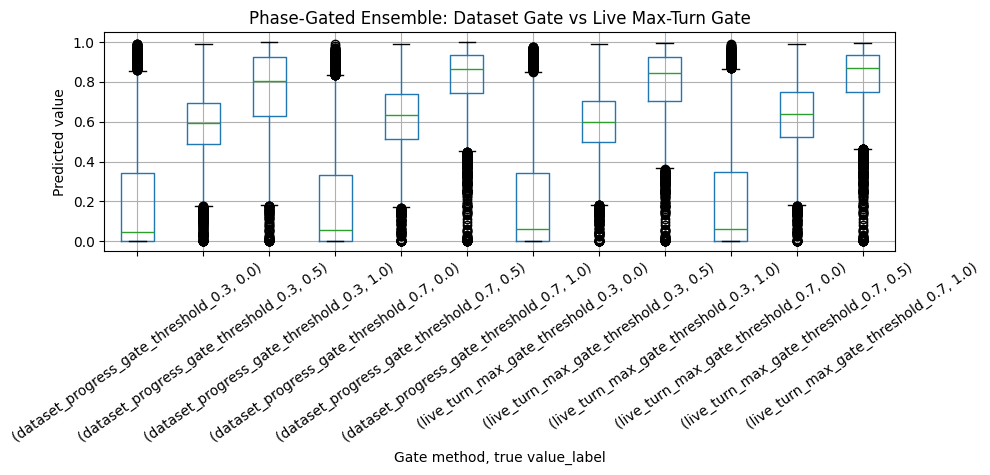

In [161]:
if "live_gate_predictions_df" not in globals() or live_gate_predictions_df.empty:
    print("No live-gate predictions available. Run the live-gate comparison cell first.")
else:
    try:
        import matplotlib.pyplot as plt

        ax = live_gate_predictions_df.boxplot(
            column="value_pred",
            by=["gate_name", "value_label"],
            figsize=(10, 5),
            rot=35,
        )
        ax.set_title("Phase-Gated Ensemble: Dataset Gate vs Live Max-Turn Gate")
        ax.set_xlabel("Gate method, true value_label")
        ax.set_ylabel("Predicted value")
        plt.suptitle("")
        plt.tight_layout()
        plt.show()
    except ImportError:
        print("matplotlib is not installed; skipping live-gate prediction plot.")
